# JP Morgan and Chase Financial Analysis

SQL Queries and Database Analysis

# Objective
Connect to the database and inspect the structure

Year over year Growth Queries

Ratio Trend Queries

Best and Worst Year Comparisons

Revenue and Expense Breakdown Queries

Export all results to CSV

In [1]:
# Importing libaries
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings

In [2]:
# Connecting to SQLite Server
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

JPM_BLUE       = '#1F4E79'
JPM_MID_BLUE   = '#2E75B6'
JPM_LIGHT_BLUE = '#9DC3E6'
JPM_RED        = '#C00000'
JPM_GREEN      = '#375623'
JPM_GOLD       = '#C9A84C'

DB_PATH     = './data/jpm_financials.db'
OUTPUT_DIR  = './data/sql_exports'
CHARTS_DIR  = './charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)

connection = sqlite3.connect(DB_PATH)

print(f"Connection to SQLite database established successfully.{DB_PATH}")


Connection to SQLite database established successfully../data/jpm_financials.db


In [3]:
# What tables and views esxist in the sql view
schema = pd.read_sql_query(
    """
    SELECT name, type 
    FROM sqlite_master
    WHERE type IN ('table', 'view')
    ORDER BY type, name
    """, connection
)

print(" Database Objects")
print(schema.to_string(index=False))

 Database Objects
            name  type
   balance_sheet table
      cash_flows table
financial_ratios table
income_statement table
  per_share_data table
     master_view  view


In [4]:
# Preview the Master View
print("Preview of the Master View")
pd.read_sql("select * from master_view", connection)

Preview of the Master View


,year,total_revenue,net_interest_income,net_income,diluted_eps,total_assets,total_equity,total_deposits,total_loans,operating_cash_flow,free_cash_flow,book_value_per_share,dividends_per_share,roe_pct,roa_pct,nim_pct,efficiency_pct,loan_to_deposit_pct,revenue_growth_pct,net_income_growth_pct
0,2022,1.277270e+11,6.671000e+10,3.767600e+10,12.09,3.665743e+12,2.923320e+11,None,None,1.071190e+11,1.071190e+11,108.390245,4.00,12.89,1.03,2.60,None,None,NaN,NaN
1,2023,1.549520e+11,8.926700e+10,4.955200e+10,16.23,3.875393e+12,3.278780e+11,None,None,1.297400e+10,1.297400e+10,121.569916,4.05,15.11,1.28,3.29,None,None,21.314992,31.521393
2,2024,1.694390e+11,9.258300e+10,5.847100e+10,19.75,4.002814e+12,3.447580e+11,None,None,-4.201200e+10,-4.201200e+10,127.828647,4.60,16.96,1.46,3.30,None,None,9.349347,17.999273
3,2025,1.818470e+11,9.544300e+10,5.704800e+10,20.02,4.424900e+12,3.624380e+11,None,None,-1.477820e+11,-1.477820e+11,134.384000,5.55,15.74,1.29,3.08,None,None,7.322989,-2.433685


# Year Over Year Growth 

We use the LAG() to calculate the Year over Year Growth Rate

In [5]:
# Year-over-Year Growth Rates for the Revenue and the Net Income for the year 2022-2025
yoy_growth = pd.read_sql(
    """
    select year,
    ROUND(total_revenue/ 1000000000.0, 1) as revenue_billion,
    ROUND(net_income/ 1000000000.0, 1) as net_income_billion,
    ROUND((total_revenue - LAG(total_revenue) OVER (ORDER BY year)) * 100.0 / LAG(total_revenue) OVER (ORDER BY year), 1) as revenue_yoy_growth_pct,

   
    ROUND((net_income - LAG(net_income) OVER (ORDER BY year)) * 100.0 / LAG(net_income) OVER (ORDER BY year), 1) as net_income_yoy_growth_pct

    FROM income_statement

    ORDER BY year

    """
, connection
)
print("Year_Over_Year_Growth_Rates")
yoy_growth

Year_Over_Year_Growth_Rates


,year,revenue_billion,net_income_billion,revenue_yoy_growth_pct,net_income_yoy_growth_pct
0,2022,127.7,37.7,NaN,NaN
1,2023,155.0,49.6,21.3,31.5
2,2024,169.4,58.5,9.3,18.0
3,2025,181.8,57.0,7.3,-2.4


In [6]:
# Year over Year Growth Rates for the EPS for the year 2022-2025
yoy_eps_growth = pd.read_sql("""
   select year, 
        diluted_eps as eps,
        ROUND((diluted_eps - LAG(diluted_eps) OVER (ORDER BY year)) * 100.0 / LAG(diluted_eps) OVER (ORDER BY year), 1 ) as eps_yoy_growth_pct,
                             
        ROUND(diluted_eps - LAG(diluted_eps) OVER (ORDER BY year), 2 ) as eps_change_usd

  from income_statement
  ORDER BY year                
                                               
                             
""", connection)

yoy_eps_growth

,year,eps,eps_yoy_growth_pct,eps_change_usd
0,2022,12.09,NaN,NaN
1,2023,16.23,34.2,4.14
2,2024,19.75,21.7,3.52
3,2025,20.02,1.4,0.27


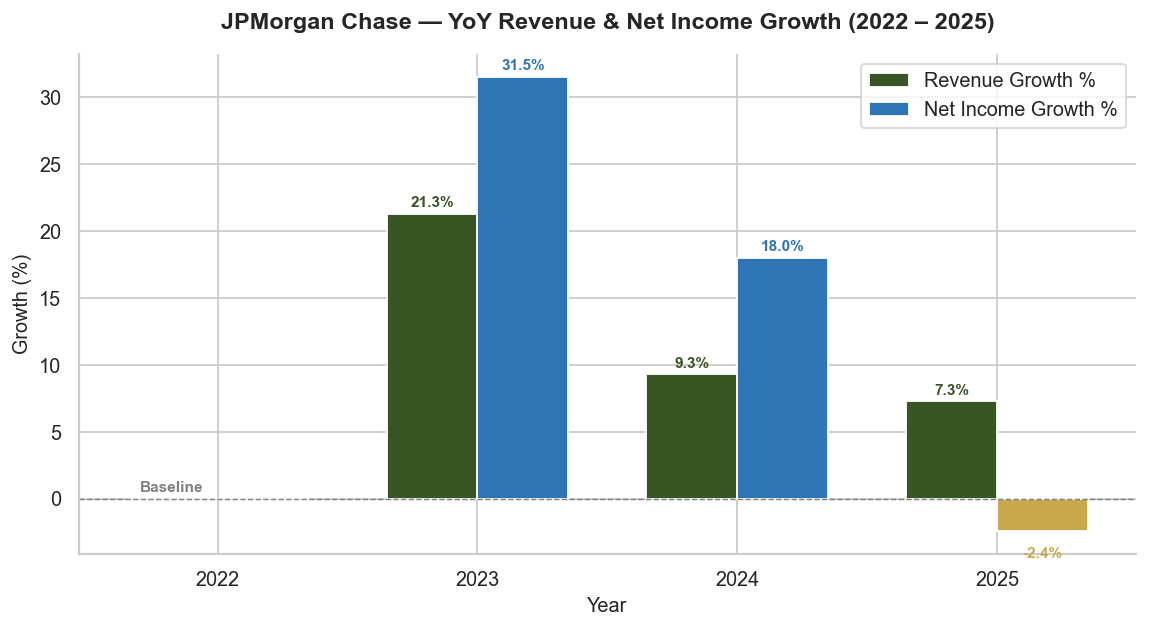

Chart saved: yoy_growth.png


In [7]:
df = yoy_growth.fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(df))
width = 0.35

bars_rev = ax.bar([i - width/2 for i in x], df['revenue_yoy_growth_pct'],
                  width=width, label='Revenue Growth %',
                  color=[JPM_GREEN if v >= 0 else JPM_RED for v in df['revenue_yoy_growth_pct']])

bars_ni  = ax.bar([i + width/2 for i in x], df['net_income_yoy_growth_pct'],
                  width=width, label='Net Income Growth %',
                  color=[JPM_MID_BLUE if v >= 0 else JPM_GOLD for v in df['net_income_yoy_growth_pct']])

for i, bar in enumerate(bars_rev):
    label = 'Baseline' if i == 0 else f'{bar.get_height():.1f}%'
    color = 'gray' if i == 0 else (JPM_GREEN if bar.get_height() >= 0 else JPM_RED)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            label, ha='center', fontsize=8.5, fontweight='bold', color=color)
    
for i, bar in enumerate(bars_ni):
    if i != 0:  
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.5 if bar.get_height() >= 0 else -2),
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=8.5, fontweight='bold',
                color=JPM_MID_BLUE if bar.get_height() >= 0 else JPM_GOLD)
        
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('JPMorgan Chase — YoY Revenue & Net Income Growth (2022 – 2025)', pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Growth (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(df['year'])
ax.legend()

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/ yoy_growth.png', bbox_inches='tight')
plt.show()
print('Chart saved: yoy_growth.png')

# Ratio Trend Analysis

Pulling ROE, ROA, NIM directly from the Financial Ratios table and comparing them to the Company BenchMarks

In [8]:
ratios = pd.read_sql("""
     select year, 
            roe_pct,
            roa_pct,
            nim_pct,
            efficiency_pct,
            loan_to_deposit_pct
     from financial_ratios
     ORDER BY year                
""", connection)
print("Financial Ratios 2022-2025")
ratios

Financial Ratios 2022-2025


,year,roe_pct,roa_pct,nim_pct,efficiency_pct,loan_to_deposit_pct
0,2022,12.89,1.03,2.60,None,None
1,2023,15.11,1.28,3.29,None,None
2,2024,16.96,1.46,3.30,None,None
3,2025,15.74,1.29,3.08,None,None


In [30]:
# Ratio VS Industry BenchMarks
benchmarks = {
    'ROE %': 10.0,
    'ROA%' : 1.0,
    'NIM %': 2.5,
    'Efficiency Ratio %': 60.0,
    'Loan to Deposit Ratio %': 50.0
}

comparison = pd.DataFrame({

    'Metric' : list(benchmarks.keys()),

    'BenchMark': list(benchmarks.values()),

    'JPM 2022': [ratios.iloc[0]['roe_pct'], ratios.iloc[0]['roa_pct'], 
                 ratios.iloc[0]['nim_pct'], ratios.iloc[0]['efficiency_pct'],
                   ratios.iloc[0]['loan_to_deposit_pct']],

    'JPM 2023': [ratios.iloc[1]['roe_pct'], ratios.iloc[1]['roa_pct'], 
                 ratios.iloc[1]['nim_pct'], ratios.iloc[1]['efficiency_pct'],
                   ratios.iloc[1]['loan_to_deposit_pct']],

    'JPM 2024': [ratios.iloc[2]['roe_pct'], ratios.iloc[2]['roa_pct'], 
                 ratios.iloc[2]['nim_pct'], ratios.iloc[2]['efficiency_pct'],
                   ratios.iloc[2]['loan_to_deposit_pct']],
    
    'JPM 2025': [ratios.iloc[3]['roe_pct'], ratios.iloc[3]['roa_pct'], 
                 ratios.iloc[3]['nim_pct'], ratios.iloc[3]['efficiency_pct'], 
                     ratios.iloc[3]['loan_to_deposit_pct']],

})

print("Comparison of JPMorgan's Financial Ratios to Industry Benchmarks")

comparison

Comparison of JPMorgan's Financial Ratios to Industry Benchmarks


,Metric,BenchMark,JPM 2022,JPM 2023,JPM 2024,JPM 2025
0,ROE %,10.0,12.89,15.11,16.96,15.74
1,ROA%,1.0,1.03,1.28,1.46,1.29
2,NIM %,2.5,2.60,3.29,3.30,3.08
3,Efficiency Ratio %,60.0,NaN,NaN,NaN,NaN
4,Loan to Deposit Ratio %,50.0,NaN,NaN,NaN,NaN


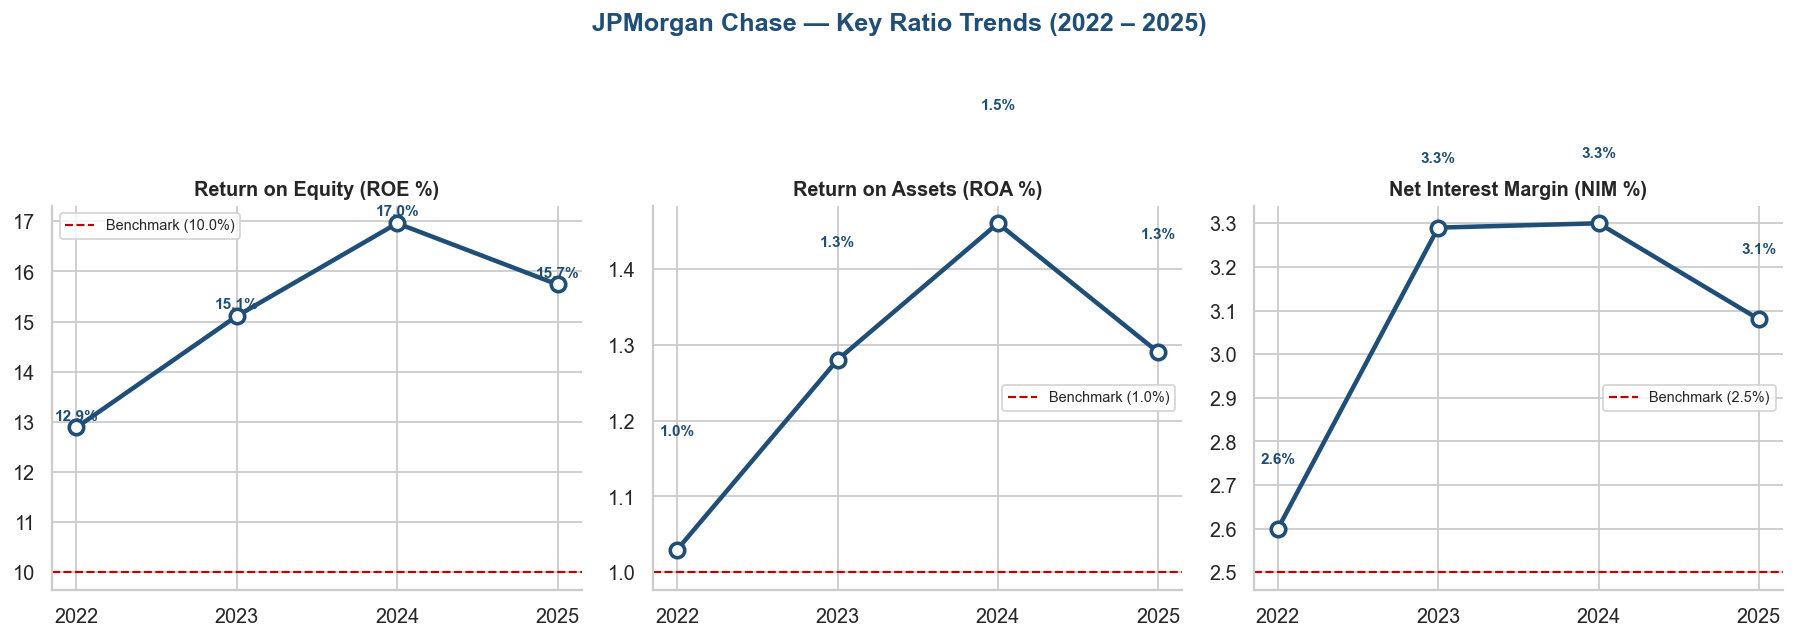

Chart saved: ratio_trend.png


In [31]:
# Chart to explore the financial ratios vs industry benchmarks
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('JPMorgan Chase — Key Ratio Trends (2022 – 2025)',
             fontsize=14, fontweight='bold', color=JPM_BLUE)

metrics = [
    ('roe_pct',  'Return on Equity (ROE %)',  10.0, axes[0]),
    ('roa_pct',  'Return on Assets (ROA %)',   1.0, axes[1]),
    ('nim_pct',  'Net Interest Margin (NIM %)',2.5, axes[2]),
]

for col, title, benchmark, ax in metrics:
    ax.plot(ratios['year'], ratios[col],
            color=JPM_BLUE, linewidth=2.5, marker='o',
            markersize=8, markerfacecolor='white',
            markeredgecolor=JPM_BLUE, markeredgewidth=2)
    ax.axhline(benchmark, color=JPM_RED, linewidth=1.2,
               linestyle='--', label=f'Benchmark ({benchmark}%)')
    
    for _, row in ratios.iterrows():
        ax.text(row['year'], row[col] + 0.15,
                f"{row[col]:.1f}%",
                ha='center', fontsize=8.5,
                fontweight='bold', color=JPM_BLUE)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(ratios['year'])
    ax.legend(fontsize=8)
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/ratio_trends.png', bbox_inches='tight')
plt.show()
print("Chart saved: ratio_trend.png")

# Efficiency Ratio and Loan to Deposit Ratio Charts

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

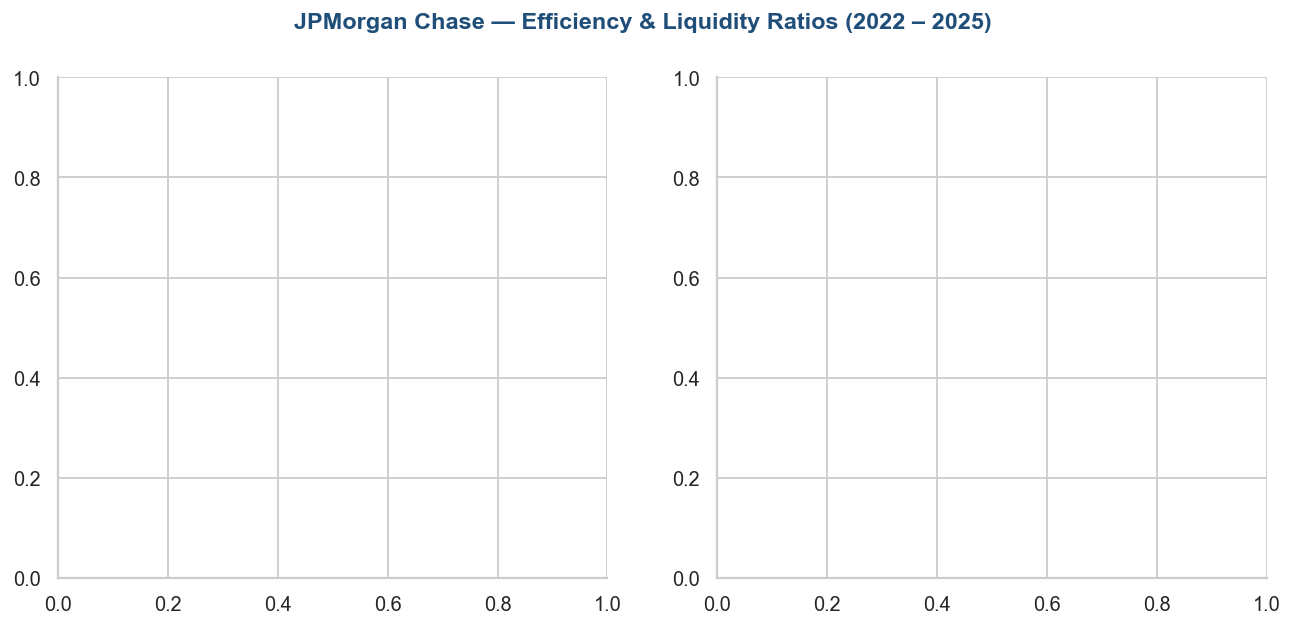

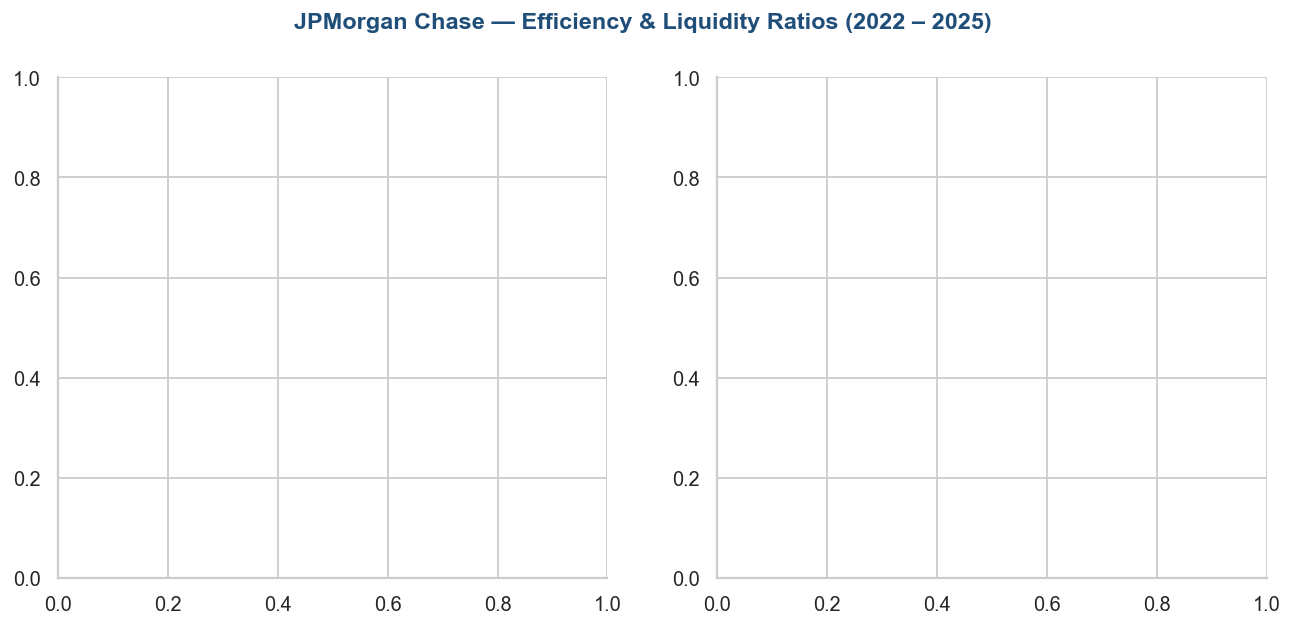

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('JPMorgan Chase — Efficiency & Liquidity Ratios (2022 – 2025)',
             fontsize=13, fontweight='bold', color=JPM_BLUE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle('JPMorgan Chase — Efficiency & Liquidity Ratios (2022 – 2025)',
             fontsize=13, fontweight='bold', color=JPM_BLUE)

# Efficiency ratio (lower = better)
bars = ax1.bar(ratios['year'], ratios['efficiency_pct'],
               color=JPM_MID_BLUE, width=0.5, edgecolor='white')
ax1.axhline(60, color=JPM_RED, linewidth=1.2, linestyle='--', label='Benchmark (60%)')

for bar, val in zip(bars, ratios['efficiency_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9,
             fontweight='bold', color=JPM_BLUE)
ax1.set_title('Efficiency Ratio % (lower = better)', fontsize=11)
ax1.set_xticks(ratios['year'])
ax1.set_ylim(0, 80)
ax1.legend(fontsize=8)
sns.despine(ax=ax1, top=True, right=True)

# Loan-to-deposit ratio
bars2 = ax2.bar(ratios['year'], ratios['loan_to_deposit_pct'],
                color=JPM_LIGHT_BLUE, width=0.5, edgecolor='white')
ax2.axhline(80, color=JPM_RED, linewidth=1.2, linestyle='--', label='Caution level (80%)')

for bar, val in zip(bars2, ratios['loan_to_deposit_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9,
             fontweight='bold', color=JPM_BLUE)
ax2.set_title('Loan-to-Deposit Ratio % (healthy: 60 – 80%)', fontsize=11)
ax2.set_xticks(ratios['year'])
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/10_efficiency_liquidity.png', bbox_inches='tight')
plt.show()
print('Chart saved: Efficiency_liquidity.png')
bars = ax1.bar(ratios['year'], ratios['efficiency_pct'],
               color=JPM_MID_BLUE, width=0.5, edgecolor='white')
ax1.axhline(60, color=JPM_RED, linewidth=1.2, linestyle='--', label='Benchmark (60%)')

for bar, val in zip(bars, ratios['efficiency_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9,
             fontweight='bold', color=JPM_BLUE)
ax1.set_title('Efficiency Ratio % (lower = better)', fontsize=11)
ax1.set_xticks(ratios['year'])
ax1.set_ylim(0, 80)
ax1.legend(fontsize=8)
sns.despine(ax=ax1, top=True, right=True)

# Loan-to-deposit ratio
bars2 = ax2.bar(ratios['year'], ratios['loan_to_deposit_pct'],
                color=JPM_LIGHT_BLUE, width=0.5, edgecolor='white')
ax2.axhline(80, color=JPM_RED, linewidth=1.2, linestyle='--', label='Caution level (80%)')
for bar, val in zip(bars2, ratios['loan_to_deposit_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9,

             fontweight='bold', color=JPM_BLUE)
ax2.set_title('Loan-to-Deposit Ratio % (healthy: 60 – 80%)', fontsize=11)
ax2.set_xticks(ratios['year'])
ax2.set_ylim(0, 100)
ax2.legend(fontsize=8)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/Efficiency_liquidity.png', bbox_inches='tight')
plt.show()
print('Chart saved: Efficiency_liquidity.png')

# Best and Worst Year Comaparisons

Using SQL to mark rank years across performance metrics


In [15]:
best_worst = pd.read_sql("""
    SELECT * FROM (
        SELECT 'Highest Revenue'    AS metric,
        year, ROUND(total_revenue / 1000000000.0, 1) AS value, 'B USD' AS unit
        FROM income_statement ORDER BY total_revenue DESC LIMIT 1
                         )

    UNION ALL
    SELECT * FROM (
         SELECT 'Lowest Revenue', year,
         ROUND(total_revenue / 1000000000.0, 1), 'B USD'
         FROM income_statement ORDER BY total_revenue ASC LIMIT 1
                         )

    UNION ALL
    SELECT * FROM (  
         SELECT 'Highest Net Income', year,
         ROUND(net_income / 1000000000.0, 1), 'B USD'
         FROM income_statement ORDER BY net_income DESC LIMIT 1
         )

    UNION ALL
    SELECT * FROM (
         SELECT 'Lowest Net Income', year,
         ROUND(net_income / 1000000000.0, 1), 'B USD'
         FROM income_statement ORDER BY net_income ASC LIMIT 1
         )

    UNION ALL
    SELECT * FROM (
        SELECT 'Highest ROE', year,
            roe_pct, '%'
        FROM financial_ratios ORDER BY roe_pct DESC LIMIT 1
    )

    UNION ALL
    SELECT * FROM (
        SELECT 'Lowest ROE', year,
            roe_pct, '%'
        FROM financial_ratios ORDER BY roe_pct ASC LIMIT 1
    )

    UNION ALL
    SELECT * FROM (
        SELECT 'Best Efficiency (Lowest)', year,
            efficiency_pct, '%'
        FROM financial_ratios ORDER BY efficiency_pct ASC LIMIT 1
    )

    UNION ALL
    SELECT * FROM (
        SELECT 'Highest Diluted EPS', year,
            diluted_eps, 'USD'
        FROM income_statement ORDER BY diluted_eps DESC LIMIT 1
    )
""", connection)

print('=== BEST & WORST YEAR PER METRIC ===')
best_worst

=== BEST & WORST YEAR PER METRIC ===


,metric,year,value,unit
0,Highest Revenue,2025,181.80,B USD
1,Lowest Revenue,2022,127.70,B USD
2,Highest Net Income,2024,58.50,B USD
3,Lowest Net Income,2022,37.70,B USD
4,Highest ROE,2024,16.96,%
5,Lowest ROE,2022,12.89,%
6,Best Efficiency (Lowest),2022,NaN,%
7,Highest Diluted EPS,2025,20.02,USD


# Full Year Rankings By Net Income


In [16]:
ranked = pd.read_sql("""
    SELECT i.year,
           ROUND(i.net_income / 1000000000.0, 1) AS net_income_USD,
           ROUND(i.total_revenue / 1000000000.0, 1) AS revenue_USD,
           r.roe_pct,
           r.roe_pct,
           r.efficiency_pct,  
           RANK() OVER (ORDER BY i.net_income DESC) AS rank_by_profit
           FROM income_statement i
           JOIN financial_ratios r ON i.year = r.year
           ORDER BY rank_by_profit""", connection)

print("Years Ranked by Net Income")
ranked

Years Ranked by Net Income


,year,net_income_USD,revenue_USD,roe_pct,roe_pct,efficiency_pct,rank_by_profit
0,2024,58.5,169.4,16.96,16.96,None,1
1,2025,57.0,181.8,15.74,15.74,None,2
2,2023,49.6,155.0,15.11,15.11,None,3
3,2022,37.7,127.7,12.89,12.89,None,4


# Revenue vs Expense BreakDown Queries

How fast are Expenses growing relative to the Revenue

In [ ]:
revenue_vs_expense = pd.read_sql("""
  SELECT  year, 
         ROUND(total_revenue/ 1000000000.0, 1) AS revenue_billion,
        ROUND( net_interest_income/ 1000000000.0, 1) AS net_interest_income_billion,
        ROUND(non_interest_revenue/ 1000000000.0 , 1)AS non_interest_income_billion,
        ROUND(net_income/ 1000000000.0, 1) AS net_income_billion,
        ROUND(net_income/ total_revenue * 100, 2) AS net_income_margin_pct,
        ROUND(non_interest_revenue/ total_revenue * 100, 2) AS non_interest_income_margin_pct
                        
  FROM income_statement
    ORDER BY year
""", connection)
print("Revenue vs Expense Breakdown")
revenue_vs_expense

,year,revenue_billion,net_interest_income_billion,non_interest_income_billion,net_income_billion,net_income_margin_pct,non_interest_income_margin_pct
0,2022,127.7,66.7,None,37.7,29.50,None
1,2023,155.0,89.3,None,49.6,31.98,None
2,2024,169.4,92.6,None,58.5,34.51,None
3,2025,181.8,95.4,None,57.0,31.37,None


# Non Interest Income vs Non Interest Revenue

In [23]:
nii_vs_nir = pd.read_sql("""
SELECT year,
       ROUND(net_interest_income / 1000000000.0, 1) AS net_interest_income_billion,
       ROUND(non_interest_revenue / 1000000000.0, 1) AS non_interest_revenue_billion,
       ROUND(net_interest_income / total_revenue * 100, 2) AS net_interest_income_margin_pct,   
       ROUND(non_interest_revenue / total_revenue * 100, 2) AS non_interest_revenue_margin_pct     
fROM income_statement
ORDER BY year        

""", connection)
print("Net Interest Income vs Non-Interest Revenue")
nii_vs_nir

Net Interest Income vs Non-Interest Revenue


,year,net_interest_income_billion,non_interest_revenue_billion,net_interest_income_margin_pct,non_interest_revenue_margin_pct
0,2022,66.7,None,52.23,None
1,2023,89.3,None,57.61,None
2,2024,92.6,None,54.64,None
3,2025,95.4,None,52.49,None


TypeError: unsupported operand type(s) for +: 'float' and 'NoneType'

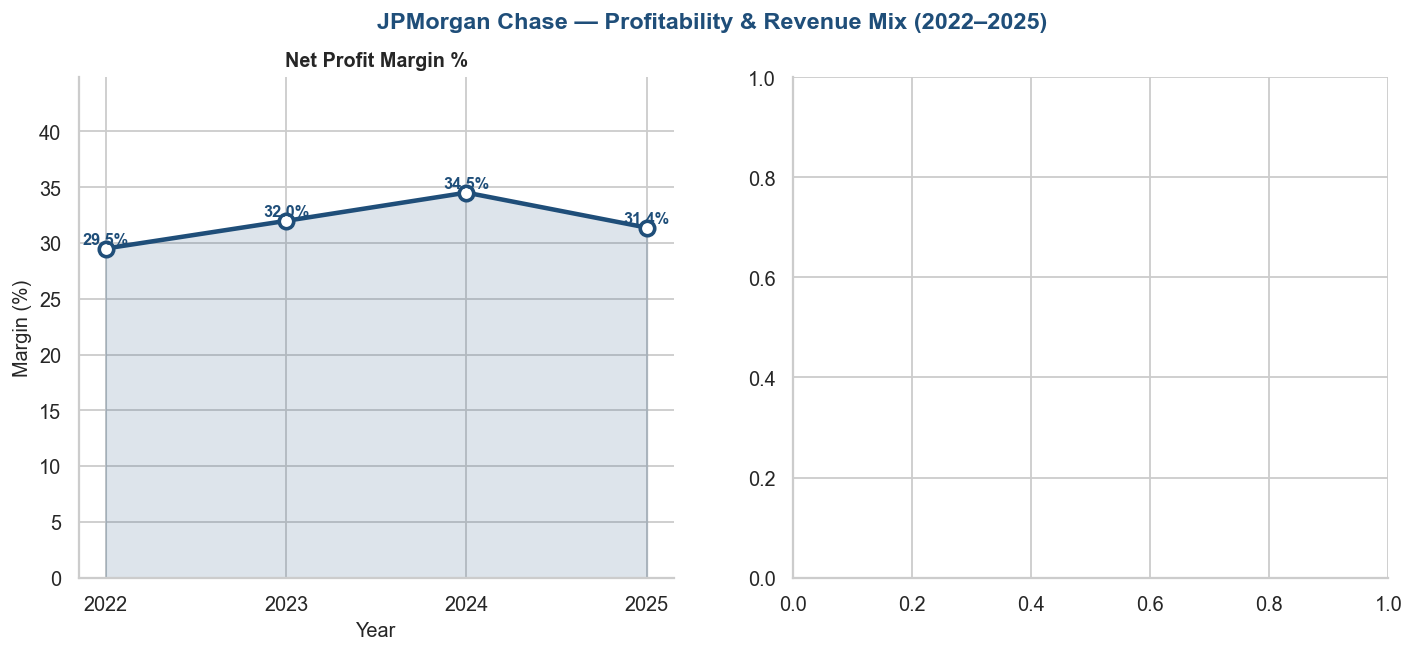

In [28]:
# ── Chart: Net Margin % trend ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('JPMorgan Chase — Profitability & Revenue Mix (2022–2025)',
             fontsize=13, fontweight='bold', color=JPM_BLUE)

# Net margin %
ax1.fill_between(revenue_vs_expense['year'], revenue_vs_expense['net_income_margin_pct'],
                 alpha=0.15, color=JPM_BLUE)
ax1.plot(revenue_vs_expense['year'], revenue_vs_expense['net_income_margin_pct'],
         color=JPM_BLUE, linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='white',
         markeredgecolor=JPM_BLUE, markeredgewidth=2)

for _, row in revenue_vs_expense.iterrows():
    ax1.text(row['year'], row['net_income_margin_pct'] + 0.4,
             f"{row['net_income_margin_pct']:.1f}%",
             ha='center', fontsize=9, fontweight='bold', color=JPM_BLUE)
ax1.set_title('Net Profit Margin %', fontsize=11)
ax1.set_xlabel('Year')
ax1.set_ylabel('Margin (%)')
ax1.set_xticks(revenue_vs_expense['year'])
ax1.set_ylim(0, revenue_vs_expense['net_income_margin_pct'].max() * 1.3)
sns.despine(ax=ax1, top=True, right=True)

# Revenue mix stacked area
ax2.stackplot(nii_vs_nir['year'],
              nii_vs_nir['net_interest_income_billion'], nii_vs_nir['non_interest_revenue_billion'],
              labels=['Net Interest Income', 'Non-Interest Revenue'],
              colors=[JPM_BLUE, JPM_LIGHT_BLUE], alpha=0.85)
ax2.set_title('Revenue Mix: NII vs Non-Interest ($B)', fontsize=11)
ax2.set_xlabel('Year')
ax2.set_ylabel('USD Billions')
ax2.set_xticks(nii_vs_nir['year'])
ax2.legend(loc='upper left', fontsize=8)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/11_margin_and_mix.png', bbox_inches='tight')
plt.show()